 ReLU vs Leaky ReLU Comparison (Dying ReLU Problem)

In [1]:
# CELL 1 — Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
# CELL 2 — Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Train samples: 60000 | Test samples: 10000


In [3]:
# CELL 3 — Define two identical architectures, differing only in activation
class MNISTNet(nn.Module):
    def __init__(self, activation="relu"):
        super().__init__()
        self.flatten = nn.Flatten()

        # Deliberately deep + narrow to encourage dying ReLU behavior
        if activation == "relu":
            act = nn.ReLU()
        elif activation == "leaky_relu":
            act = nn.LeakyReLU(negative_slope=0.01)
        else:
            raise ValueError("Unknown activation")

        self.net = nn.Sequential(
            nn.Linear(28 * 28, 64),
            act,
            nn.Linear(64, 64),
            act,
            nn.Linear(64, 64),
            act,
            nn.Linear(64, 64),
            act,
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model_relu = MNISTNet(activation="relu").to(device)
model_leaky = MNISTNet(activation="leaky_relu").to(device)

# Use a deliberately large learning rate — this increases the chance
# of neurons receiving a large negative update and "dying" under plain ReLU
LR = 0.05

In [4]:
# CELL 4 — Training function (reusable for both models)
def train_model(model, loader, epochs=10, lr=0.05):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)  # plain SGD makes dying ReLU more visible than Adam

    history = {"loss": [], "accuracy": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_loss = running_loss / len(loader)
        acc = 100 * correct / total
        history["loss"].append(avg_loss)
        history["accuracy"].append(acc)
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f} | Train Acc: {acc:.2f}%")

    return history

In [5]:
# CELL 5 — Train Network A (ReLU)
print("Training Network A (ReLU)...")
history_relu = train_model(model_relu, train_loader, epochs=10, lr=LR)

Training Network A (ReLU)...
Epoch 1/10 — Loss: 0.7179 | Train Acc: 76.65%
Epoch 2/10 — Loss: 0.1774 | Train Acc: 94.62%
Epoch 3/10 — Loss: 0.1234 | Train Acc: 96.37%
Epoch 4/10 — Loss: 0.0986 | Train Acc: 97.03%
Epoch 5/10 — Loss: 0.0814 | Train Acc: 97.48%
Epoch 6/10 — Loss: 0.0690 | Train Acc: 97.88%
Epoch 7/10 — Loss: 0.0593 | Train Acc: 98.19%
Epoch 8/10 — Loss: 0.0522 | Train Acc: 98.35%
Epoch 9/10 — Loss: 0.0452 | Train Acc: 98.55%
Epoch 10/10 — Loss: 0.0403 | Train Acc: 98.70%


In [6]:
# CELL 6 — Train Network B (Leaky ReLU)
print("Training Network B (Leaky ReLU)...")
history_leaky = train_model(model_leaky, train_loader, epochs=10, lr=LR)

Training Network B (Leaky ReLU)...
Epoch 1/10 — Loss: 0.7118 | Train Acc: 76.72%
Epoch 2/10 — Loss: 0.1770 | Train Acc: 94.60%
Epoch 3/10 — Loss: 0.1232 | Train Acc: 96.18%
Epoch 4/10 — Loss: 0.0945 | Train Acc: 97.08%
Epoch 5/10 — Loss: 0.0767 | Train Acc: 97.66%
Epoch 6/10 — Loss: 0.0635 | Train Acc: 98.00%
Epoch 7/10 — Loss: 0.0541 | Train Acc: 98.35%
Epoch 8/10 — Loss: 0.0474 | Train Acc: 98.55%
Epoch 9/10 — Loss: 0.0430 | Train Acc: 98.59%
Epoch 10/10 — Loss: 0.0353 | Train Acc: 98.88%


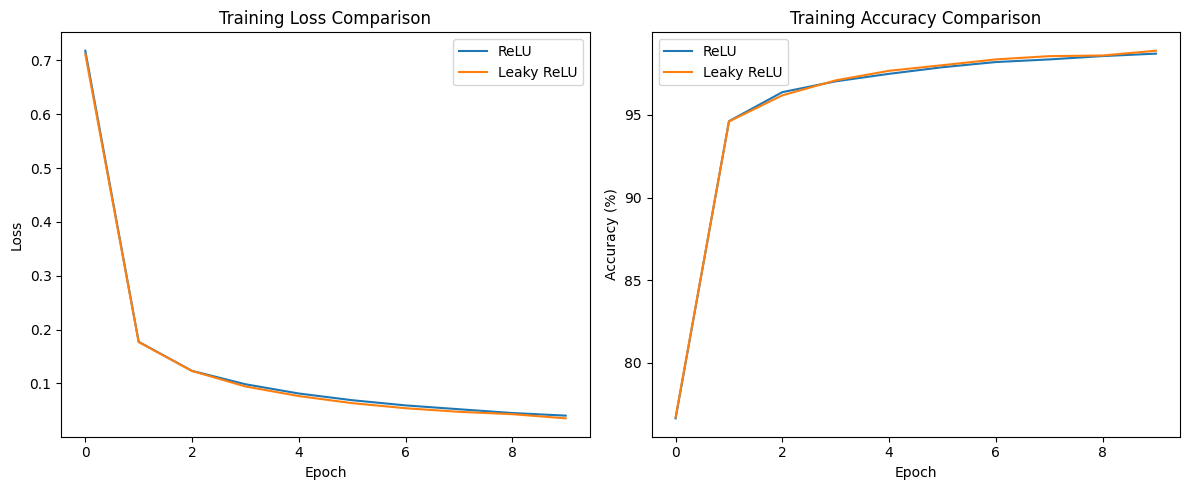

In [7]:
# CELL 7 — Compare training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_relu["loss"], label="ReLU")
plt.plot(history_leaky["loss"], label="Leaky ReLU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_relu["accuracy"], label="ReLU")
plt.plot(history_leaky["accuracy"], label="Leaky ReLU")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Comparison")
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# CELL 8 — Detect "dead" neurons (outputs of exactly 0 across the whole batch)
def count_dead_neurons(model, loader):
    model.eval()
    activations = []

    def hook(module, input, output):
        activations.append(output.detach())

    # Hook onto the first activation layer after the first Linear layer
    first_act_layer = model.net[1]
    handle = first_act_layer.register_forward_hook(hook)

    with torch.no_grad():
        images, _ = next(iter(loader))
        images = images.to(device)
        model(images)

    handle.remove()
    act_output = activations[0]  # shape: [batch, num_neurons]

    # A neuron is "dead" if it outputs exactly 0 for every sample in the batch
    dead_mask = (act_output == 0).all(dim=0)
    num_dead = dead_mask.sum().item()
    total_neurons = act_output.shape[1]

    return num_dead, total_neurons

dead_relu, total_relu = count_dead_neurons(model_relu, test_loader)
dead_leaky, total_leaky = count_dead_neurons(model_leaky, test_loader)

print(f"ReLU network: {dead_relu}/{total_relu} neurons dead in first layer")
print(f"Leaky ReLU network: {dead_leaky}/{total_leaky} neurons dead in first layer")

ReLU network: 0/64 neurons dead in first layer
Leaky ReLU network: 0/64 neurons dead in first layer
